Train images shape: (5734, 18, 288, 288)
Min precipitation: 0.0
Max precipitation: 0.47125235
Mean precipitation: 0.0014155908
Std precipitation: 0.0025928104


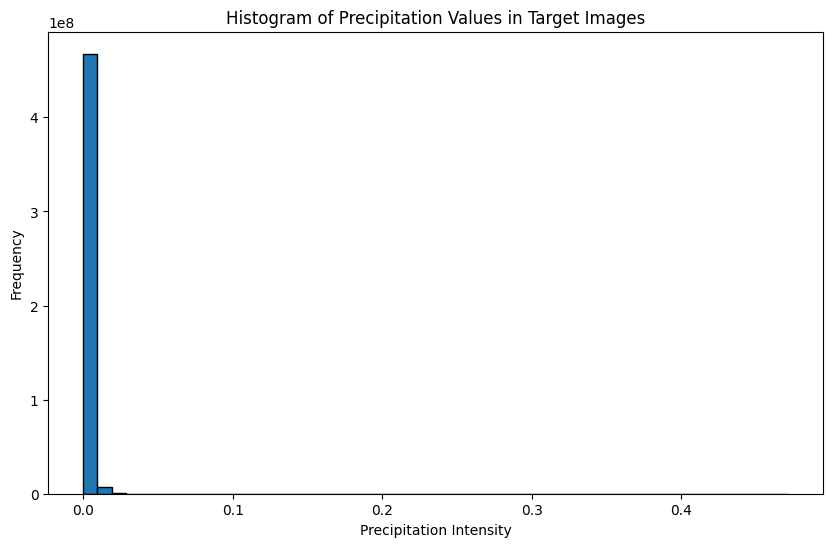


Bin ranges and corresponding percentages:
Range 0.0000 - 0.0094: 98.32%
Range 0.0094 - 0.0189: 1.43%
Range 0.0189 - 0.0283: 0.18%
Range 0.0283 - 0.0377: 0.04%
Range 0.0377 - 0.0471: 0.01%
Range 0.0471 - 0.0566: 0.01%
Range 0.0566 - 0.0660: 0.00%
Range 0.0660 - 0.0754: 0.00%
Range 0.0754 - 0.0848: 0.00%
Range 0.0848 - 0.0943: 0.00%
Range 0.0943 - 0.1037: 0.00%
Range 0.1037 - 0.1131: 0.00%
Range 0.1131 - 0.1225: 0.00%
Range 0.1225 - 0.1320: 0.00%
Range 0.1320 - 0.1414: 0.00%
Range 0.1414 - 0.1508: 0.00%
Range 0.1508 - 0.1602: 0.00%
Range 0.1602 - 0.1697: 0.00%
Range 0.1697 - 0.1791: 0.00%
Range 0.1791 - 0.1885: 0.00%
Range 0.1885 - 0.1979: 0.00%
Range 0.1979 - 0.2074: 0.00%
Range 0.2074 - 0.2168: 0.00%
Range 0.2168 - 0.2262: 0.00%
Range 0.2262 - 0.2356: 0.00%
Range 0.2356 - 0.2451: 0.00%
Range 0.2451 - 0.2545: 0.00%
Range 0.2545 - 0.2639: 0.00%
Range 0.2639 - 0.2733: 0.00%
Range 0.2733 - 0.2828: 0.00%
Range 0.2828 - 0.2922: 0.00%
Range 0.2922 - 0.3016: 0.00%
Range 0.3016 - 0.3110: 0.00%

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the path to your .h5 file
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]  # shape: (N, T, H, W)
    print("Train images shape:", train_images.shape)

    # Assume the last frame in each sequence is the target.
    target_frame_index = train_images.shape[1] - 1
    
    all_values = []
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        all_values.append(target_img.flatten())
    
    # Concatenate all pixel values from all target images.
    all_values = np.concatenate(all_values)

# Print basic stats
print("Min precipitation:", np.min(all_values))
print("Max precipitation:", np.max(all_values))
print("Mean precipitation:", np.mean(all_values))
print("Std precipitation:", np.std(all_values))

# Plot histogram
num_bins = 50
hist, bin_edges = np.histogram(all_values, bins=num_bins)
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge")
plt.xlabel("Precipitation Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Precipitation Values in Target Images")
plt.show()

# Print bin ranges and percentages
bin_percentages = 100 * hist / hist.sum()
print("\nBin ranges and corresponding percentages:")
for i in range(len(hist)):
    print(f"Range {bin_edges[i]:.4f} - {bin_edges[i+1]:.4f}: {bin_percentages[i]:.2f}%")


Train images shape: (5734, 18, 288, 288)
Min precipitation: 0.0
Max precipitation: 0.47125235
Mean precipitation: 0.0014155908
Std precipitation: 0.0025928104
Quantile-based boundaries: [0.         0.00020907 0.0008363  0.00229981]
Full bin edges: [0.00000000e+00 0.00000000e+00 2.09073798e-04 8.36295192e-04
 2.29981192e-03 4.71252352e-01]


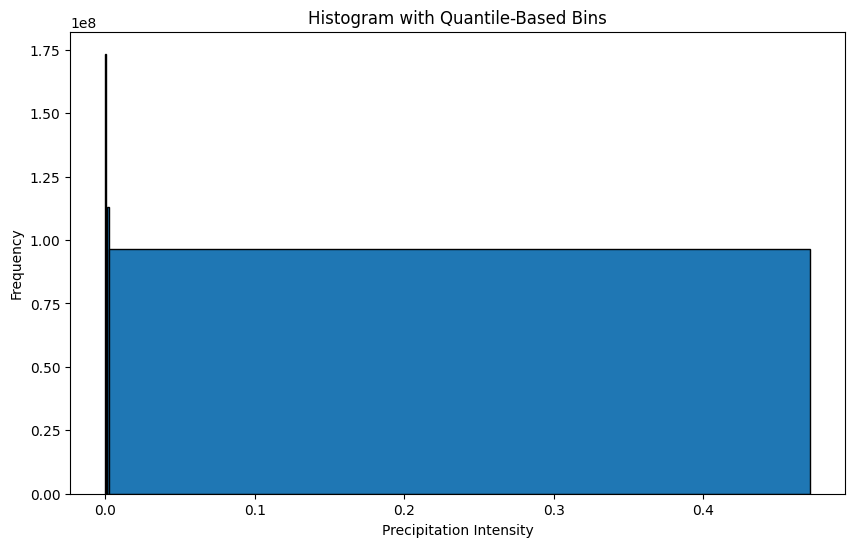


Bin Ranges and Percentages:
Range 0.00000 - 0.00000: 0.00%
Range 0.00000 - 0.00021: 36.47%
Range 0.00021 - 0.00084: 19.42%
Range 0.00084 - 0.00230: 23.80%
Range 0.00230 - 0.47125: 20.32%


In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the path to your .h5 file
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]  # shape: (N, T, H, W)
    print("Train images shape:", train_images.shape)

    # Assume the last frame in each sequence is the target.
    target_frame_index = train_images.shape[1] - 1
    
    all_values = []
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        all_values.append(target_img.flatten())
    
    # Concatenate all pixel values from all target images.
    all_values = np.concatenate(all_values)

# Print basic stats
print("Min precipitation:", np.min(all_values))
print("Max precipitation:", np.max(all_values))
print("Mean precipitation:", np.mean(all_values))
print("Std precipitation:", np.std(all_values))

# Let's create 5 buckets total. That means we need 4 boundaries.
# We'll use quantiles to decide the boundary points so that each bucket
# roughly contains the same fraction of pixels.
num_buckets = 5
# For 5 buckets, we need 4 internal boundaries at quantiles [0.2, 0.4, 0.6, 0.8].
# (You could also try [0.25, 0.5, 0.75] for quartiles, etc.)
quantiles = np.linspace(0, 1, num_buckets + 1)  # [0, 0.2, 0.4, 0.6, 0.8, 1.0]
internal_quantiles = quantiles[1:-1]           # [0.2, 0.4, 0.6, 0.8]

boundaries = np.quantile(all_values, internal_quantiles)
print("Quantile-based boundaries:", boundaries)

# For convenience, define full bin edges from min to max:
bin_edges = np.concatenate(([all_values.min()], boundaries, [all_values.max()]))
print("Full bin edges:", bin_edges)

# Compute histogram with these bin edges
hist, bin_edges_used = np.histogram(all_values, bins=bin_edges)
bin_percentages = 100.0 * hist / hist.sum()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges_used[:-1], hist, width=np.diff(bin_edges_used), edgecolor="black", align="edge")
plt.xlabel("Precipitation Intensity")
plt.ylabel("Frequency")
plt.title("Histogram with Quantile-Based Bins")
plt.show()

# Print out each bin's range and percentage of pixels
print("\nBin Ranges and Percentages:")
for i in range(len(hist)):
    print(f"Range {bin_edges_used[i]:.5f} - {bin_edges_used[i+1]:.5f}: {bin_percentages[i]:.2f}%")
